# Clinical v22 집계 재현 노트북

동일 디렉터리의 동결 `PUBLIC_REPORT.json`만 읽는다. 이 파일은 `report.json`에서 추출한 집계다. 개인별 배열을 저장하거나 재학습하지 않는다. 세 seed는 독립 fit이며 확률 앙상블과 구분한다.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
R=json.loads(Path('PUBLIC_REPORT.json').read_text(encoding='utf-8'))
assert R['version']=='clinical_followup_v22' and len(R['contrasts'])==16
print('full n:',R['n_full'],'nutrition n:',R['n_nutrition'],'models:',len(R['models']))

full n: 4068 nutrition n: 3784 models: 82


## 16개 사전 대조: 점추정, 개별 구간, 동시구간

한 PSU draw의 배율을 full `wt_itvex`와 nutrition `wt_tot`에 공통 적용했다. 영양 대조는 같은 영양 참여자끼리만 계산했다. 0 수직선은 AP 차이가 없다는 기준이다.

,contrast,arm,estimate,individual_low,individual_high,simultaneous_low,simultaneous_high,seed_sd
0,full/family_EPF_vs_LR,full,0.00131,-0.00170,0.00420,-0.00313,0.00575,0.00132
1,full/family_EPF_vs_MLP,full,0.00053,-0.00240,0.00315,-0.00359,0.00465,0.00164
2,full/family_MLP_vs_LR,full,0.00078,-0.00028,0.00190,-0.00084,0.00241,0.00032
3,full/input_EPF,full,-0.00151,-0.00921,0.00532,-0.01204,0.00901,0.00129
4,full/input_LR,full,-0.00456,-0.01142,0.00190,-0.01442,0.00530,0.00000
5,full/input_MLP,full,-0.00270,-0.00946,0.00372,-0.01243,0.00704,0.00022
6,full/mode_full10_vs_binary4_EPF,full,0.00012,-0.00131,0.00163,-0.00208,0.00231,0.00154
7,full/mode_full10_vs_binary4_MLP,full,-0.00055,-0.00193,0.00085,-0.00262,0.00152,0.00042
8,full/transfer_vs_scratch_EPF,full,-0.00092,-0.00305,0.00095,-0.00391,0.00206,0.00156
9,full/transfer_vs_scratch_MLP,full,-0.00000,-0.00095,0.00095,-0.00142,0.00141,0.00082


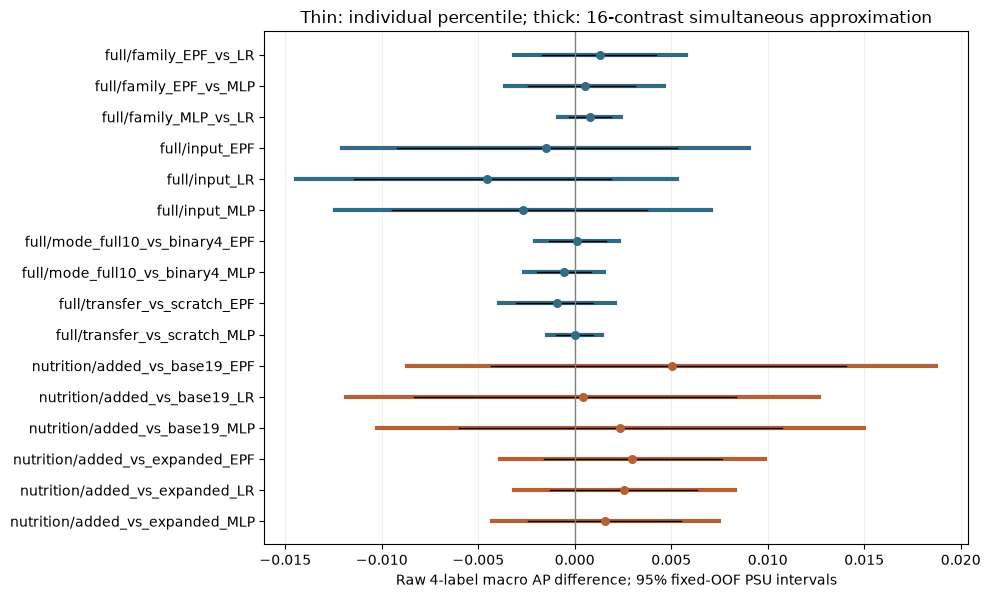

In [2]:
C=R['contrasts']
rows=[{'contrast':k,'arm':v['arm'],'estimate':v['estimate'],'individual_low':v['paired_psu_ci95'][0],'individual_high':v['paired_psu_ci95'][1],'simultaneous_low':v['simultaneous_ci95'][0],'simultaneous_high':v['simultaneous_ci95'][1],'seed_sd':v['paired_seed_sd']} for k,v in C.items()]
D=pd.DataFrame(rows)
display(D.round(5))
fig,ax=plt.subplots(figsize=(10, max(5,.38*len(D))))
for i,row in D.iterrows():
    color='#326b86' if row['arm']=='full' else '#b46133'
    ax.plot([row['simultaneous_low'],row['simultaneous_high']],[i,i],color=color,lw=3)
    ax.plot([row['individual_low'],row['individual_high']],[i,i],color='black',lw=1)
    ax.scatter(row['estimate'],i,color=color,s=30,zorder=3)
ax.axvline(0,color='gray',lw=1)
ax.set_yticks(range(len(D)),D['contrast']);ax.invert_yaxis()
ax.set_xlabel('Raw 4-label macro AP difference; 95% fixed-OOF PSU intervals')
ax.set_title('Thin: individual percentile; thick: 16-contrast simultaneous approximation')
ax.grid(axis='x',alpha=.2);fig.tight_layout();display(fig);plt.close(fig)

## 입력·모드·계열별 clean 점수

각 점수는 동일 모델의 세 독립 seed OOF AP 평균이다. 회귀5 raw는 순위 점수다. 전체와 영양의 조사 가중치·대상이 달라 색깔로 직접 비교하지 않는다.

In [3]:
M=pd.DataFrame([{'model':key,**{k:v[k] for k in ('arm','panel','mode','family','policy','stage','n','weight','raw_macro_ap','raw_macro_brier','calibrated_macro_brier')}} for key,v in R['models'].items()])
display(M.sort_values(['arm','panel','mode','family','policy']).round(5))

,model,arm,panel,mode,family,policy,stage,n,weight,raw_macro_ap,raw_macro_brier,calibrated_macro_brier
0,full_base19_binary4_AP_EPF,full,base19,binary4,EPF,AP,selected,4068,wt_itvex,0.36308,0.10586,0.10622
3,full_base19_binary4_BCE_EPF,full,base19,binary4,EPF,BCE,selected,4068,wt_itvex,0.36658,0.10549,0.10603
1,full_base19_binary4_AP_LR,full,base19,binary4,LR,AP,selected,4068,wt_itvex,0.36125,0.10619,0.10653
4,full_base19_binary4_BCE_LR,full,base19,binary4,LR,BCE,selected,4068,wt_itvex,0.36832,0.10544,0.10603
2,full_base19_binary4_AP_MLP,full,base19,binary4,MLP,AP,selected,4068,wt_itvex,0.35840,0.10668,0.10644
...,...,...,...,...,...,...,...,...,...,...,...,...
72,nutrition_expanded_nutrition_binary4_BCE_LR,nutrition,expanded_nutrition,binary4,LR,BCE,selected,3784,wt_tot,0.37439,0.10530,0.10647
70,nutrition_expanded_nutrition_binary4_AP_MLP,nutrition,expanded_nutrition,binary4,MLP,AP,selected,3784,wt_tot,0.36380,0.10696,0.10696
73,nutrition_expanded_nutrition_binary4_BCE_MLP,nutrition,expanded_nutrition,binary4,MLP,BCE,selected,3784,wt_tot,0.37547,0.10520,0.10626
74,nutrition_expanded_nutrition_regression5_MSE_R...,nutrition,expanded_nutrition,regression5,Ridge,MSE,selected,3784,wt_tot,0.37680,NaN,0.10587


## 전이 recipe의 fold별 출력 계약

전이와 matched scratch의 주 AP는 모든 fold에서 공통인 보정 전 네 소견 확률로 계산했다. 일부 fold에만 있는 direct any·수치·joint 지표는 부분 fold 평균을 내지 않고 비교 불가 사유를 기록한다.

In [4]:
recipe=[]
for key,v in R['models'].items():
    if v['stage'] in ('transfer','matched_scratch'):
        recipe.append({'model':key,'fold_modes':v['chosen_mode_by_fold'],'raw_oof_score_scale':v['raw_oof_score_scale'],'not_comparable_clean':{k:x for k,x in v['optional_not_comparable'].items() if k.startswith('exploratory/clean/') or '/' not in k}})
display(pd.DataFrame(recipe) if recipe else 'No development recipe models')

,model,fold_modes,raw_oof_score_scale,not_comparable_clean
0,scratch_common_BCE_EPF,"{'1': 'state16', '2': 'aux9', '3': 'binary4', ...",raw_component_probability_common_across_recipe...,"{'adjusted_any': {'available_folds': [2, 3, 4,..."
1,scratch_common_BCE_MLP,"{'1': 'full10', '2': 'state16', '3': 'binary4'...",raw_component_probability_common_across_recipe...,"{'adjusted_any': {'available_folds': [1, 3], '..."
2,transfer_common_BCE_EPF,"{'1': 'state16', '2': 'aux9', '3': 'binary4', ...",raw_component_probability_common_across_recipe...,"{'adjusted_any': {'available_folds': [2, 3, 4,..."
3,transfer_common_BCE_MLP,"{'1': 'full10', '2': 'state16', '3': 'binary4'...",raw_component_probability_common_across_recipe...,"{'adjusted_any': {'available_folds': [1, 3], '..."


## 수치 보조 목적과 16상태 분포의 탐색 지표

각 seed 안에서 표준화 MSE를 fit 변환과 fold 조사 가중합으로 pooled하고 RMSE를 계산한 뒤 세 seed의 지표를 평균했다. 원단위 RMSE/MAE는 서로 다른 단위의 다섯 검사별로 보존한다. 독립곱16은 비교용 참조분포다.

In [5]:
numeric=[];joint=[]
for key,v in R['models'].items():
    x=v['exploratory_clean']
    if 'continuous_standardized_MSE' in x:
        row={'model':key,'standardized_MSE':x['continuous_standardized_MSE']}
        for name,value in zip(R['design']['continuous_target_order'],x['continuous_original_RMSE_by_target']):
            row[name+'_RMSE_original']=value
        for name,value in zip(R['design']['continuous_target_order'],x['continuous_original_MAE_by_target']):
            row[name+'_MAE_original']=value
        numeric.append(row)
    for stage in ('raw_joint16','calibrated_joint16','raw_independent_product16_reference','calibrated_independent_product16_reference'):
        if stage+'_weighted_NLL' in x:
            joint.append({'model':key,'distribution':stage,'NLL':x[stage+'_weighted_NLL'],'Brier_sum16':x[stage+'_weighted_Brier'],'exact_state_accuracy':x[stage+'_exact_state_accuracy']})
display(pd.DataFrame(numeric).round(5) if numeric else 'No numeric head')
display(pd.DataFrame(joint).round(5) if joint else 'No joint distribution')

,model,standardized_MSE,HE_glu_RMSE_original,HE_sbp_RMSE_original,HE_dbp_RMSE_original,HE_TG_RMSE_original,HE_HDL_st2_RMSE_original,HE_glu_MAE_original,HE_sbp_MAE_original,HE_dbp_MAE_original,HE_TG_MAE_original,HE_HDL_st2_MAE_original
0,full_base19_regression5_MSE_Ridge,0.72592,12.17721,9.03899,7.73039,73.52496,11.82639,6.35388,6.92620,5.97571,40.76343,9.21035
1,full_expanded_aux9_AP_EPF,0.72569,12.14023,9.04214,7.72258,73.69342,11.84444,6.34289,6.94874,5.97547,40.79058,9.25102
2,full_expanded_aux9_AP_MLP,0.73296,12.14011,9.10418,7.76376,74.03716,11.90205,6.36280,7.00014,6.00919,41.16868,9.31185
3,full_expanded_aux9_BCE_EPF,0.72333,12.11896,9.04512,7.71526,73.46134,11.82209,6.32214,6.93618,5.96683,40.65667,9.23754
4,full_expanded_aux9_BCE_MLP,0.72429,12.12461,9.05041,7.71411,73.54060,11.83284,6.32611,6.93579,5.96019,40.72874,9.24954
5,full_expanded_full10_ANY_BCE_EPF,0.72486,12.12704,9.06319,7.72073,73.35782,11.82180,6.33756,6.95696,5.96614,40.70318,9.23355
6,full_expanded_full10_ANY_BCE_MLP,0.72311,12.11556,9.03759,7.70765,73.62452,11.81687,6.32597,6.92750,5.95234,40.72181,9.23468
7,full_expanded_full10_AP_EPF,0.72464,12.12529,9.04657,7.71744,73.67572,11.82991,6.32092,6.93745,5.96346,40.79769,9.24215
8,full_expanded_full10_AP_MLP,0.72987,12.15386,9.07548,7.74232,73.82483,11.87604,6.37447,6.97865,5.98854,41.01858,9.28067
9,full_expanded_full10_BCE_EPF,0.72331,12.12085,9.04923,7.71634,73.37191,11.81654,6.33054,6.94100,5.96636,40.62571,9.23091


,model,distribution,NLL,Brier_sum16,exact_state_accuracy
0,full_base19_binary4_AP_EPF,raw_independent_product16_reference,1.38132,0.53397,0.61203
1,full_base19_binary4_AP_EPF,calibrated_independent_product16_reference,1.38667,0.53623,0.61245
2,full_base19_binary4_AP_LR,raw_independent_product16_reference,1.38879,0.53522,0.61131
3,full_base19_binary4_AP_LR,calibrated_independent_product16_reference,1.39245,0.53702,0.61173
4,full_base19_binary4_AP_MLP,raw_independent_product16_reference,1.39067,0.53643,0.60914
...,...,...,...,...,...
132,nutrition_expanded_nutrition_binary4_BCE_LR,calibrated_independent_product16_reference,1.39442,0.53811,0.61491
133,nutrition_expanded_nutrition_binary4_BCE_MLP,raw_independent_product16_reference,1.37638,0.53357,0.61924
134,nutrition_expanded_nutrition_binary4_BCE_MLP,calibrated_independent_product16_reference,1.39181,0.53772,0.61574
135,nutrition_expanded_nutrition_regression5_MSE_R...,calibrated_independent_product16_reference,1.38839,0.53847,0.62069


## 모드별 차이 히트맵

동일 full/expanded, 동일 family·BCE 정책의 binary4에서 뺀 AP 차이다. 색 범위는 관측 차이의 절댓값 최대를 양·음에 대칭 적용하고 0을 가운데에 둔다. 원점수 자체와 구간은 위 표·대조 그림을 확인한다.

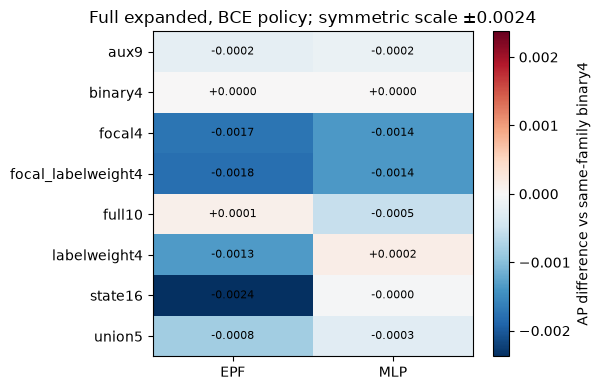

In [6]:
Q=M[(M.arm=='full')&(M.panel=='expanded')&(M.stage=='selected')&(M.family.isin(['EPF','MLP']))&(M.policy=='BCE')]
H=Q.pivot(index='mode',columns='family',values='raw_macro_ap')
base=H.loc['binary4']
Delta=H-base
vmax=max(.001,float(np.nanmax(np.abs(Delta.to_numpy()))))
fig,ax=plt.subplots(figsize=(6,max(4,.45*len(Delta))))
im=ax.imshow(Delta.to_numpy(),cmap='RdBu_r',vmin=-vmax,vmax=vmax,aspect='auto')
ax.set_xticks(range(len(Delta.columns)),Delta.columns)
ax.set_yticks(range(len(Delta.index)),Delta.index)
for i in range(len(Delta.index)):
    for j in range(len(Delta.columns)):
        ax.text(j,i,f'{Delta.iloc[i,j]:+.4f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='AP difference vs same-family binary4')
ax.set_title(f'Full expanded, BCE policy; symmetric scale ±{vmax:.4f}')
fig.tight_layout();display(fig);plt.close(fig)

## 13개 수정 stress 보기와 계산량

보기별 AP는 조건부 강건성 기술이다. test 보기로 후보를 재선택하지 않았다. 추론 시간은 평가기에서 측정된 경우에만 보인다.

In [7]:
views=[]
for key,v in R['models'].items():
    if v['arm']=='full' and v['panel']=='expanded' and v['mode']=='binary4' and v['policy']=='BCE':
        for view,ap in v['views_raw_macro_ap'].items():
            views.append({'model':key,'view':view,'raw_macro_ap':ap})
display(pd.DataFrame(views).round(5))
cost=[]
for key,v in R['models'].items():
    if key in R['primary_ids']:
        t=v['training'];cost.append({'model':key,'parameters':t.get('stored_parameters',{}).get('mean'),'fit_seconds_per_unit':t.get('fit_seconds',{}).get('mean'),'inference_ms_per_1000':t.get('inference_ms_per_1000',{}).get('mean'),'initial_epoch_diagnostic_units':t.get('initial_epoch_diagnostic_units'),'selected_epoch_zero_units':t.get('selected_epoch_zero_units')})
display(pd.DataFrame(cost).round(2))

,model,view,raw_macro_ap
0,full_expanded_binary4_BCE_EPF,HE_BMI_gaussian_fitSD10pct_all_observed,0.36502
1,full_expanded_binary4_BCE_EPF,HE_BMI_gaussian_fitSD25pct_all_observed,0.36482
2,full_expanded_binary4_BCE_EPF,HE_wc_gaussian_fitSD10pct_all_observed,0.36458
3,full_expanded_binary4_BCE_EPF,HE_wc_gaussian_fitSD25pct_all_observed,0.35646
4,full_expanded_binary4_BCE_EPF,behavior_missing,0.35083
5,full_expanded_binary4_BCE_EPF,body_missing,0.24709
6,full_expanded_binary4_BCE_EPF,clean,0.36507
7,full_expanded_binary4_BCE_EPF,missing10,0.35397
8,full_expanded_binary4_BCE_EPF,missing20_0,0.33178
9,full_expanded_binary4_BCE_EPF,missing20_1,0.34452


,model,parameters,fit_seconds_per_unit,inference_ms_per_1000,initial_epoch_diagnostic_units,selected_epoch_zero_units
0,full_base19_binary4_BCE_EPF,9903.0,10.61,28.07,15,None
1,full_base19_binary4_BCE_LR,292.0,NaN,0.07,N/A,N/A
2,full_base19_binary4_BCE_MLP,22815.2,1.95,1.32,15,None
3,full_expanded_binary4_BCE_EPF,8688.6,10.86,20.88,15,None
4,full_expanded_binary4_BCE_LR,460.0,NaN,0.09,N/A,N/A
5,full_expanded_binary4_BCE_MLP,18016.8,2.33,1.16,15,None
6,full_expanded_full10_BCE_EPF,18270.6,15.56,42.42,15,None
7,full_expanded_full10_BCE_MLP,24235.6,3.39,1.47,15,None
8,nutrition_base19_binary4_BCE_EPF,12495.0,11.77,33.80,15,None
9,nutrition_base19_binary4_BCE_LR,292.0,NaN,0.06,N/A,N/A


## 실제 학습 장치와 자원 정책

처음 484개 완료 단위는 auto의 CPU/CUDA 혼합 실행이었다. 이후 신규 신경망 단위는 CUDA 강제, 기존 CPU 재개 1건만 원래 장치에서 완료했다. 제한 단계의 후보 튜닝·선택 모델 학습은 단일 worker/논리 코어 11/Idle/Torch·BLAS 1 thread 정책이었다. 이후 전이는 별도 승인된 전체 CPU affinity·Normal 우선순위에서 실행했다. 실제 코어 수와 장치는 아래 동결 기록을 확인한다. fit_seconds는 동일 하드웨어 통제 비교가 아닌 실제 실행 시간이다. source40 로지스틱 기준선은 수렴 실패 후 반복 상한만 5,000→20,000으로 늘렸다. solver·L2·tol·C 격자·가중치 정규화는 유지했고, 청년/main 학습에는 적용하지 않았다. 전이−scratch에는 장치·난수·수치 경로가 섞여 순수 자료 추가의 인과 대조가 아니다. source 선택 epoch 0은 자료 학습 효과로 세지 않는다.

In [8]:
X=R['resource_execution']
display(pd.DataFrame([{'policy_status':X.get('status'),'auto_completed_at_switch':X.get('auto_completed_at_switch'),'new_neural_device':X.get('new_neural_unit_device'),'worker_count':X.get('worker_count'),'logical_core':X.get('logical_core'),'affinity_mask':X.get('affinity_mask'),'priority':X.get('priority'),'torch_blas_threads':X.get('torch_blas_threads')}]))
F=X.get('fast_transfer',{}); print('full-resource transfer:',F.get('status'))
if F.get('process_limits'):
    display(pd.DataFrame([F['process_limits']]))
N=X.get('source_baseline_numerical_amendment',{})
if N.get('status')=='passed':
    display(pd.DataFrame([{'scope':N['scope'],'baseline_count':N['baseline_count'],**N['convergence_summary']}]))
display(pd.DataFrame([{'device':k,'frozen_training_units':v} for k,v in X.get('actual_frozen_training_unit_devices',{}).items()]))
T=X.get('transfer_execution',{})
print('target-scratch device mismatches:',T.get('pairs_with_device_mismatch'),'source epoch-zero units:',T.get('source_epoch_zero_units'))
if T.get('pairs'):
    display(pd.DataFrame(T['pairs']).round(4))

,policy_status,auto_completed_at_switch,new_neural_device,worker_count,logical_core,affinity_mask,priority,torch_blas_threads
0,applied,484,cuda:0,1,11,2048,Idle,1


full-resource transfer: verified_launch


,affinity_mask,blas_threads,logical_cpus_available,priority_class,torch_threads
0,4095,1,12,NORMAL_PRIORITY_CLASS,1


,scope,baseline_count,all_fits_below_new_max_iter,fits_exceeding_old_max_iter,max_component_n_iter,max_union_n_iter,new_max_iter,old_max_iter
0,source40_baselines_only,10,True,62,10102,7963,20000,5000


,device,frozen_training_units
0,cpu,365
1,cuda:0,1253


target-scratch device mismatches: 5 source epoch-zero units: 0


,chosen_mode,family,fold,matched_scratch_device,seed,source_best_BCE_epoch,source_device,source_epoch_zero,target_device,target_scratch_device_match
0,state16,EPF,1,cuda:0,42,8,cuda:0,False,cuda:0,True
1,state16,EPF,1,cuda:0,43,8,cuda:0,False,cuda:0,True
2,state16,EPF,1,cuda:0,44,8,cuda:0,False,cuda:0,True
3,aux9,EPF,2,cpu,42,28,cuda:0,False,cuda:0,False
4,aux9,EPF,2,cuda:0,43,75,cuda:0,False,cuda:0,True
5,aux9,EPF,2,cuda:0,44,37,cuda:0,False,cuda:0,True
6,binary4,EPF,3,cpu,42,8,cuda:0,False,cuda:0,False
7,binary4,EPF,3,cuda:0,43,12,cuda:0,False,cuda:0,True
8,binary4,EPF,3,cuda:0,44,9,cuda:0,False,cuda:0,True
9,focal_labelweight4,EPF,4,cuda:0,42,42,cuda:0,False,cuda:0,True


In [9]:
labels=['glucose','blood_pressure','triglyceride','HDL']
per_label=[]
for key,v in R['models'].items():
    if key in R['primary_ids']:
        for stage,records in v['per_label_clean'].items():
            for label,metric in zip(labels,records):
                per_label.append({'model':key,'stage':stage,'label':label,'AP':metric.get('ap'),'AUC':metric.get('auc'),'Brier':metric.get('brier')})
display(pd.DataFrame(per_label).round(5))
screen=[]
for key,v in R['models'].items():
    if key in R['primary_ids']:
        for risk,policies in v['screening_clean'].items():
            for target,metric in policies.items():
                screen.append({'model':key,'risk':risk,'development_target':target,'held_out_sensitivity':metric.get('sensitivity'),'held_out_referral':metric.get('referral_rate')})
display(pd.DataFrame(screen).round(5))

,model,stage,label,AP,AUC,Brier
0,full_base19_binary4_BCE_EPF,calibrated_components,glucose,0.36725,0.79690,0.09606
1,full_base19_binary4_BCE_EPF,calibrated_components,blood_pressure,0.26646,0.75769,0.08369
2,full_base19_binary4_BCE_EPF,calibrated_components,triglyceride,0.44434,0.80546,0.12426
3,full_base19_binary4_BCE_EPF,calibrated_components,HDL,0.37603,0.75987,0.12012
4,full_base19_binary4_BCE_EPF,raw_components,glucose,0.37699,0.80466,NaN
...,...,...,...,...,...,...
163,transfer_common_BCE_MLP,calibrated_components,HDL,0.36934,0.75757,0.12082
164,transfer_common_BCE_MLP,raw_components,glucose,0.37122,0.79648,NaN
165,transfer_common_BCE_MLP,raw_components,blood_pressure,0.26702,0.75051,NaN
166,transfer_common_BCE_MLP,raw_components,triglyceride,0.44233,0.79882,NaN


,model,risk,development_target,held_out_sensitivity,held_out_referral
0,full_base19_binary4_BCE_EPF,adjusted_any,0.9,0.86814,0.64020
1,full_base19_binary4_BCE_EPF,adjusted_any,0.95,0.92198,0.75445
2,full_base19_binary4_BCE_EPF,raw_any,0.9,0.87153,0.64543
3,full_base19_binary4_BCE_EPF,raw_any,0.95,0.92587,0.75353
4,full_base19_binary4_BCE_EPF,raw_any_precal,0.9,0.86849,0.63632
...,...,...,...,...,...
105,nutrition_expanded_nutrition_binary4_BCE_MLP,adjusted_any,0.95,0.91829,0.74073
106,nutrition_expanded_nutrition_binary4_BCE_MLP,raw_any,0.9,0.86627,0.64668
107,nutrition_expanded_nutrition_binary4_BCE_MLP,raw_any,0.95,0.91991,0.74471
108,nutrition_expanded_nutrition_binary4_BCE_MLP,raw_any_precal,0.9,0.87237,0.64819


In [10]:
grad=[]
for key,v in R['models'].items():
    if key in R['primary_ids']:
        g=v['training'].get('first_gradient_and_update',{})
        for field,value in g.items():
            if isinstance(value,dict) and 'mean' in value:
                grad.append({'model':key,'field':field,'group':'all','mean':value['mean']})
            elif isinstance(value,dict):
                for group,summary in value.items():
                    grad.append({'model':key,'field':field,'group':group,'mean':summary['mean']})
display(pd.DataFrame(grad).round(5) if grad else 'Gradient/update aggregate unavailable')

,model,field,group,mean
0,full_base19_binary4_BCE_EPF,group_actual_update_norm,field_matrix,0.08080
1,full_base19_binary4_BCE_EPF,group_actual_update_norm,field_other,0.01206
2,full_base19_binary4_BCE_EPF,group_actual_update_norm,linear_skip,0.00033
3,full_base19_binary4_BCE_EPF,group_gradient_norm_preclip,field_matrix,0.00830
4,full_base19_binary4_BCE_EPF,group_gradient_norm_preclip,field_other,0.00247
...,...,...,...,...
107,transfer_common_BCE_MLP,group_actual_update_norm,linear_skip,0.00219
108,transfer_common_BCE_MLP,group_gradient_norm_preclip,field_matrix,0.01858
109,transfer_common_BCE_MLP,group_gradient_norm_preclip,field_other,0.00320
110,transfer_common_BCE_MLP,group_gradient_norm_preclip,linear_skip,0.05226


## 별도 연구 경로와 해석 경계

v21 seed 확률 앙상블·의뢰 정책은 새 v22 학습 cell이 아니다. 미국 공통 5입력 연구도 원 19/38입력 모델의 직접 외부 검증이 아니다. 미국 screening decision은 `not_defined`다.

In [11]:
S=R['separate_studies']; P=S['v21_ensemble_policy']; E=S['external_common_core']
print('v21 ensemble/policy:',P.get('status')); print('US common-core:',E.get('status'))
if P.get('aggregate'):
    rows=[]
    for model,item in P['aggregate'].get('models_clean_raw',{}).items():
        rows.append({'v21_ensemble_model':model,'ensemble_AP':item.get('ensemble_ap'),'mean_member_AP':item.get('mean_member_ap')})
    display(pd.DataFrame(rows).round(6))
    p=P['aggregate'].get('all_policy_clean_point',{}).get('enhanced_BCE_EPF',{})
    rows=[{'policy':name,**item} for name,item in p.items() if name.startswith('0.9/direct/adjusted_any/')]
    display(pd.DataFrame(rows).round(6))
if E.get('model_results'):
    print('US decision:',E.get('US_screening_cutoff_and_decision_metrics'))
    display(pd.json_normalize(E['model_results']).head().round(6))

v21 ensemble/policy: complete
US common-core: completed_aggregate_only


,v21_ensemble_model,ensemble_AP,mean_member_AP
0,LR_AP,0.361252,0.361252
1,LR_BCE,0.368316,0.368316
2,enhanced_AP_EPF,0.363401,0.362684
3,enhanced_AP_MLP,0.358938,0.357676
4,enhanced_BCE_EPF,0.366936,0.366256
5,enhanced_BCE_MLP,0.367530,0.367310
6,plain_AP_EPF,0.365512,0.364047
7,plain_AP_MLP,0.357177,0.355684
8,plain_BCE_EPF,0.367204,0.366440
9,plain_BCE_MLP,0.368482,0.367612


,policy,referral_rate,sensitivity,specificity
0,0.9/direct/adjusted_any/conservative,0.716940,0.904441,0.397942
1,0.9/direct/adjusted_any/weighted,0.637197,0.866372,0.503220


US decision: not_defined


,EPF_AP.adjusted_any.score_reason,EPF_AP.adjusted_any.score_status,EPF_AP.adjusted_any.weighted_ap_by_label,EPF_AP.adjusted_any.weighted_brier,EPF_AP.adjusted_any.weighted_macro_ap,EPF_AP.adjusted_any.weighted_macro_ap_reason,EPF_AP.adjusted_any.weighted_macro_ap_status,EPF_AP.adjusted_any.weighted_nll,EPF_AP.calibrated_components.score_reason,EPF_AP.calibrated_components.score_status,...,MLP_BCE.raw_components.PSU_interval_status,MLP_BCE.raw_components.PSU_valid_replicates,MLP_BCE.raw_components.score_reason,MLP_BCE.raw_components.score_status,MLP_BCE.raw_components.weighted_ap_by_label,MLP_BCE.raw_components.weighted_brier,MLP_BCE.raw_components.weighted_macro_ap,MLP_BCE.raw_components.weighted_macro_ap_reason,MLP_BCE.raw_components.weighted_macro_ap_status,MLP_BCE.raw_components.weighted_nll
0,None,estimable,[0.686489714379121],0.234836,0.68649,None,estimable,0.683096,None,estimable,...,estimable,2000,None,estimable,"[0.40571015003348376, 0.23287961434124257, 0.3...",0.16045,0.374628,None,estimable,0.505122


## 공개 패키지 raw38→의뢰 정책 실행 시간

합성 입력의 7개 fold1 공개 예시에 한정한다. 기존 모델표의 batch256 forward-only 시간과 이 표의 전처리·보정·threshold 포함 시간을 섞어 비교하지 않는다. package/model 로딩과 파일 IO는 측정에서 제외된다.

In [12]:
B=R['public_runtime_benchmark']
print('runtime status:',B['status'])
if B.get('conditions'):
    cols=['model_id','family','device','batch_size','median_ms_per_batch','p95_ms_per_batch','median_batch_amortized_ms_per_person','median_throughput_people_per_second']
    display(pd.DataFrame(B['conditions'])[cols].round(4))

runtime status: measured


,model_id,family,device,batch_size,median_ms_per_batch,p95_ms_per_batch,median_batch_amortized_ms_per_person,median_throughput_people_per_second
0,binary4_BCE_EPF,EPF,cpu,1,1.4954,1.5523,1.4954,668.7174
1,binary4_BCE_EPF,EPF,cpu,256,3.5894,4.3429,0.0140,71320.1187
2,binary4_BCE_EPF,EPF,cuda,1,4.7991,7.6329,4.7991,208.3724
3,binary4_BCE_EPF,EPF,cuda,256,4.6486,5.7557,0.0182,55070.9361
4,binary4_BCE_MLP,MLP,cpu,1,0.5788,0.6399,0.5788,1727.5633
5,binary4_BCE_MLP,MLP,cpu,256,0.8563,1.1019,0.0033,298960.6446
6,binary4_BCE_MLP,MLP,cuda,1,0.8394,1.1560,0.8394,1191.3271
7,binary4_BCE_MLP,MLP,cuda,256,1.0441,1.1678,0.0041,245187.2426
8,full10_BCE_EPF,EPF,cpu,1,1.9481,2.2151,1.9481,513.3207
9,full10_BCE_EPF,EPF,cpu,256,12.8580,18.0540,0.0502,19909.7838


전체 16개 동시구간은 고정 OOF 예측과 재표집 틀에 조건부인 근사다. 전이에는 40세 이상 source 자료와 추가 학습 계산량이 든다. EPF 내부 4/6단계는 개인 추적 시계열이 아니다. 이 실험은 로컬 지도학습이며 Jev 가중치·teacher API·RLCD 증류를 실행하지 않았다. 네 소견은 미인지 측정 이상으로 확진 질환 분류가 아니다. 우월성·임상 성과·배포 가능성을 입증하지 않는다.